In [2]:
# Roll No: 24BAD047

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [3]:
df = pd.read_csv(r"C:\Users\Admin\Desktop\4_sem\ML\EX_NO_6\income_random_forest.csv")

In [4]:
df.columns = df.columns.str.strip()

In [5]:
target_col = None
for col in df.columns:
    if col.lower() == "income":
        target_col = col
        break

if target_col is None:
    raise Exception("Income column not found!")

In [6]:
df[target_col] = df[target_col].astype(str).str.strip()

In [7]:
df[target_col] = df[target_col].replace({
    '<=50K':0, '>50K':1,
    '<=50k':0, '>50k':1
})

df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
df = df[df[target_col].notna()]
df[target_col] = df[target_col].astype(int)

In [8]:
X = pd.get_dummies(df.drop(target_col, axis=1))
y = df[target_col]

print("Class Distribution:\n", y.value_counts())

Class Distribution:
 Income
0    80
1    40
Name: count, dtype: int64


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
trees = [10, 50, 100]
acc_list = []

for t in trees:
    rf = RandomForestClassifier(n_estimators=t, random_state=42)
    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)
    acc = accuracy_score(y_test, pred)
    acc_list.append(acc)
    print(f"Trees={t} → Accuracy={acc:.4f}")

Trees=10 → Accuracy=1.0000
Trees=50 → Accuracy=1.0000
Trees=100 → Accuracy=1.0000


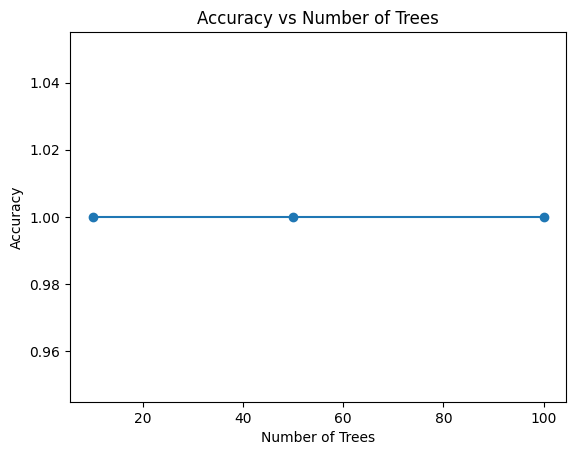

In [11]:
plt.figure()
plt.plot(trees, acc_list, marker='o')
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Number of Trees")
plt.show()

In [12]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


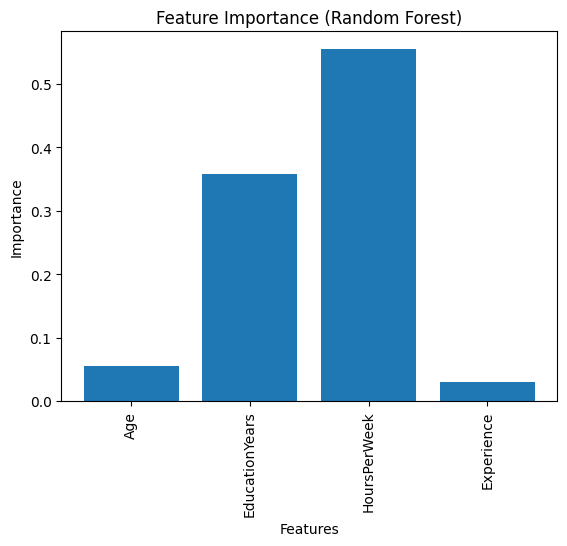

In [13]:
features = X.columns
importance = rf.feature_importances_

plt.figure()
plt.bar(features, importance)
plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.show()